<a href="https://colab.research.google.com/github/guadalupeltissera-png/Challenge_TelecomX/blob/main/TelecomX_LATAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#📌 Extracción

In [1]:
import pandas as pd
url = 'https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json'

df = pd.read_json(url)
pd.set_option('display.max_columns', None)

df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


#🔧 Transformación

In [2]:
customer_df = pd.json_normalize(df['customer'])
phone_df = pd.json_normalize(df['phone'])
internet_df = pd.json_normalize(df['internet'])
account_df = pd.json_normalize(df['account'])

df_normalizado = pd.concat(
    [df[['customerID', 'Churn']],
     customer_df,
     phone_df,
     internet_df,
     account_df],
    axis=1
)

df_normalizado.head()


,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [3]:
df_normalizado.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


In [4]:
df_normalizado['Contract'].unique()
df_normalizado['PaymentMethod'].unique()
df_normalizado['InternetService'].unique()
df_normalizado['gender'].unique()

array(['Female', 'Male'], dtype=object)

In [5]:
df_normalizado.isnull().sum().sort_values(ascending=False)

,0
customerID,0
Churn,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0


In [6]:
df_normalizado['Churn'].value_counts(dropna=False)

,count
Churn,
No,5174
Yes,1869
,224


In [7]:
df_normalizado['Churn'].unique()

array(['No', 'Yes', ''], dtype=object)

In [10]:
df_normalizado['Churn'] = df_normalizado['Churn'].apply(
    lambda x: 1 if x == 'Yes' else 0
)

In [11]:
df_normalizado['Charges.Total'] = pd.to_numeric(df_normalizado['Charges.Total'], errors='coerce')

In [12]:
df_normalizado.duplicated().sum()

np.int64(0)

In [13]:
df_normalizado.dtypes

,0
customerID,object
Churn,int64
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object


In [14]:
df_normalizado['Churn']

,Churn
0,0
1,0
2,1
3,1
4,1
...,...
7262,0
7263,1
7264,0
7265,0


In [15]:
df_normalizado.columns = df_normalizado.columns.str.lower().str.replace('.', '_')
df_normalizado

,customerid,churn,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,charges_monthly,charges_total
0,0002-ORFBO,0,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.30
1,0003-MKNFE,0,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.40
2,0004-TLHLJ,1,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,0011-IGKFF,1,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,0013-EXCHZ,1,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,0,Female,0,No,No,13,Yes,No,DSL,Yes,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.90
7263,9992-RRAMN,1,Male,0,Yes,No,22,Yes,Yes,Fiber optic,No,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.70
7264,9992-UJOEL,0,Male,0,No,No,2,Yes,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7265,9993-LHIEB,0,Male,0,Yes,Yes,67,Yes,No,DSL,Yes,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65


In [16]:
df_normalizado['cuentas_diarias'] = df_normalizado['charges_monthly'] / 30

In [17]:
cols_binarias = [
    'partner',
    'dependents',
    'phoneservice',
    'paperlessbilling',
    'multiplelines',
    'deviceprotection',
    'techsupport',
    'streamingtv',
    'streamingmovies',
    'onlinesecurity',
    'onlinebackup'
]

for col in cols_binarias:
    df_normalizado[col] = df_normalizado[col].apply(lambda x: 1 if x == 'Yes' else 0)

In [18]:
df_normalizado.head()

,customerid,churn,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,charges_monthly,charges_total,cuentas_diarias
0,0002-ORFBO,0,Female,0,1,1,9,1,0,DSL,0,1,0,1,1,0,One year,1,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,0,Male,0,0,0,9,1,1,DSL,0,0,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,1,Male,0,0,0,4,1,0,Fiber optic,0,0,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,1,Male,1,1,0,13,1,0,Fiber optic,0,1,1,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,1,Female,1,1,0,3,1,0,Fiber optic,0,0,0,1,1,0,Month-to-month,1,Mailed check,83.9,267.40,2.796667


In [19]:
df_normalizado.isnull().sum().sort_values(ascending=False)

,0
charges_total,11
customerid,0
gender,0
seniorcitizen,0
partner,0
churn,0
dependents,0
tenure,0
multiplelines,0
phoneservice,0


In [20]:
df_normalizado['charges_total'] = pd.to_numeric(
    df_normalizado['charges_total'], errors='coerce'
)

df_normalizado['charges_total'].fillna(0, inplace=True)

/tmp/ipykernel_162/52637893.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_normalizado['charges_total'].fillna(0, inplace=True)


In [21]:
df_normalizado.isnull().sum().sort_values(ascending=False)

,0
customerid,0
churn,0
gender,0
seniorcitizen,0
partner,0
dependents,0
tenure,0
phoneservice,0
multiplelines,0
internetservice,0


#📊 Carga y análisis

In [22]:
df_normalizado.describe()

,churn,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,paperlessbilling,charges_monthly,charges_total,cuentas_diarias
count,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000
mean,0.257190,0.162653,0.484106,0.300124,32.346498,0.902711,0.421770,0.285950,0.344571,0.342782,0.289528,0.383927,0.387505,0.593230,64.720098,2277.182035,2.157337
std,0.437115,0.369074,0.499782,0.458343,24.571773,0.296371,0.493876,0.451897,0.475261,0.474672,0.453575,0.486374,0.487214,0.491265,30.129572,2268.648587,1.004319
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,0.000000,0.608333
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,35.425000,396.200000,1.180833
50%,0.000000,0.000000,0.000000,0.000000,29.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,70.300000,1389.200000,2.343333
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,89.875000,3778.525000,2.995833
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,118.750000,8684.800000,3.958333


In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly as px

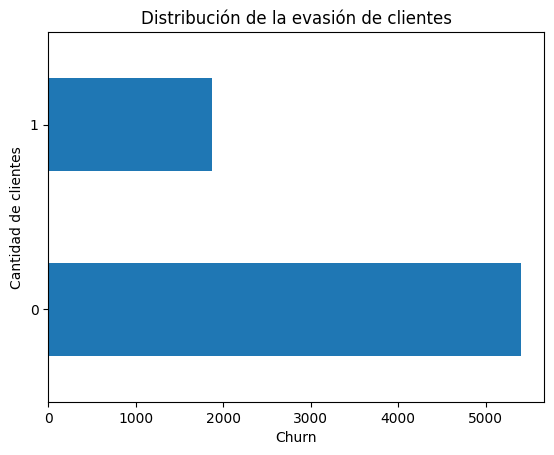

In [33]:
conteo = df_normalizado['churn'].value_counts()

plt.figure()
conteo.plot(kind='barh')
plt.xlabel('Churn')
plt.ylabel('Cantidad de clientes')
plt.title('Distribución de la evasión de clientes')
plt.show()

/tmp/ipykernel_162/614333679.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


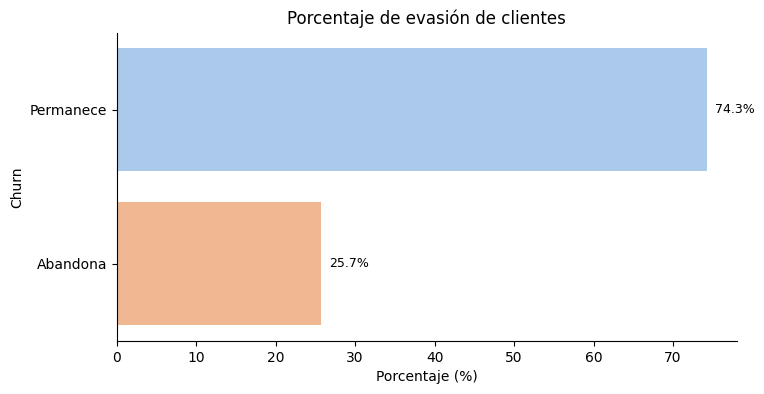

In [52]:
porcentaje_churn = df_normalizado['churn'].value_counts(normalize=True).sort_index()*100

porcentaje_churn.index = ['Permanece', 'Abandona']

fig,ax = plt.subplots(figsize=(8,4))

sns.barplot(
    x=porcentaje_churn.values,
    y=porcentaje_churn.index,
    orient='h',
    ax=ax,
    palette='pastel')

ax.set(title='Porcentaje de evasión de clientes',xlabel='Porcentaje (%)',ylabel='Churn')

for i, j in enumerate(porcentaje_churn):
    ax.text(j + 1, i, f'{j:.1f}%',
            color='black',
            fontsize=9,
            ha='left',
            va='center')

sns.despine()

plt.show()

In [53]:
tabla_contract = pd.crosstab(
    df_normalizado['contract'],
    df_normalizado['churn'],
    normalize='index'
) * 100

tabla_contract

churn,0,1
contract,,
Month-to-month,58.676654,41.323346
One year,89.071758,10.928242
Two year,97.246127,2.753873


In [74]:
tabla_gender = pd.crosstab(
    df_normalizado['gender'],
    df_normalizado['churn'],
    normalize='index'
) * 100

tabla_gender

churn,0,1
gender,,
Female,73.858575,26.141425
Male,74.693878,25.306122


In [76]:
tabla_paymentmethod = pd.crosstab(
    df_normalizado['paymentmethod'],
    df_normalizado['churn'],
    normalize='index'
) * 100

tabla_paymentmethod

churn,0,1
paymentmethod,,
Bank transfer (automatic),83.763373,16.236627
Credit card (automatic),85.204082,14.795918
Electronic check,56.196319,43.803681
Mailed check,81.501502,18.498498


In [77]:
tabla_internetservice = pd.crosstab(
    df_normalizado['internetservice'],
    df_normalizado['churn'],
    normalize='index'
) * 100

tabla_internetservice

churn,0,1
internetservice,,
DSL,81.551447,18.448553
Fiber optic,59.443402,40.556598
No,92.852625,7.147375


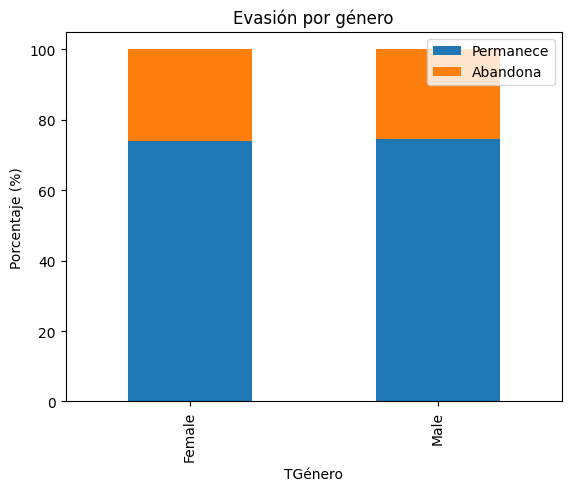

In [89]:
tabla_gender.plot(kind='bar', stacked=True)

plt.title('Evasión por género')
plt.ylabel('Porcentaje (%)')
plt.xlabel('TGénero')
plt.legend(['Permanece', 'Abandona'])
plt.show()


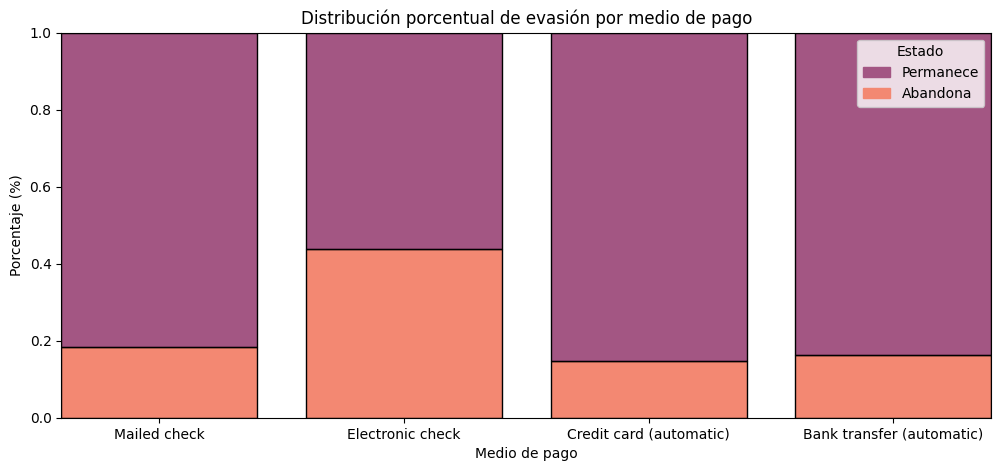

In [88]:
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(12,5))

sns.histplot(
    data=df_normalizado,
    x='paymentmethod',
    hue='churn',
    multiple='fill',
    stat='percent',
    shrink=0.8,
    ax=ax,
    palette='rocket'
)

ax.set(
    title='Distribución porcentual de evasión por medio de pago',
    ylabel='Porcentaje (%)',
    xlabel='Medio de pago'
)

permanece_patch = mpatches.Patch(color='#a35683', label='Permanece')
abandona_patch = mpatches.Patch(color='#f38872', label='Abandona')

ax.legend(handles=[permanece_patch, abandona_patch], title='Estado')

plt.show()

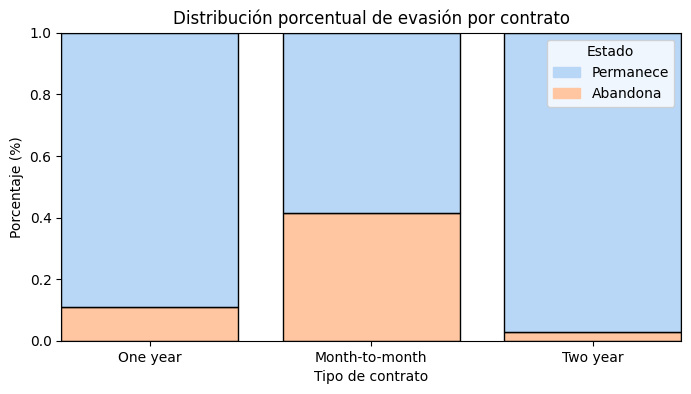

In [90]:
fig, ax = plt.subplots(figsize=(8,4))

sns.histplot(
    data=df_normalizado,
    x='contract',
    hue='churn',
    multiple='fill',
    stat='percent',
    shrink=0.8,
    ax=ax,
    palette='pastel'
)

ax.set(
    title='Distribución porcentual de evasión por contrato',
    ylabel='Porcentaje (%)',
    xlabel='Tipo de contrato'
)

permanece_patch = mpatches.Patch(color='#b8d6f6', label='Permanece')
abandona_patch = mpatches.Patch(color='#ffc6a1', label='Abandona')

ax.legend(handles=[permanece_patch, abandona_patch], title='Estado')

plt.show()

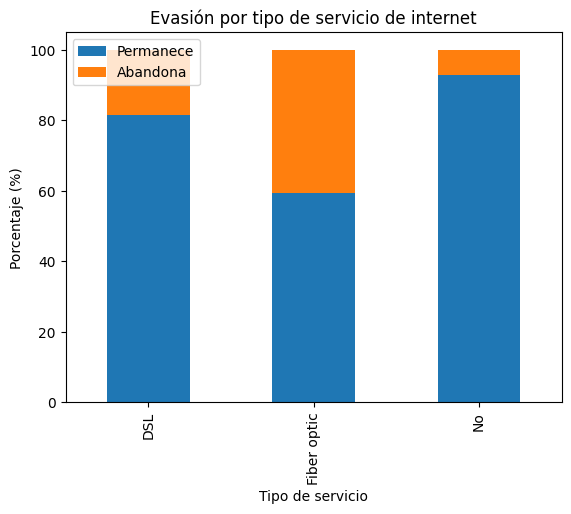

In [91]:
tabla_internetservice.plot(kind='bar', stacked=True)

plt.title('Evasión por tipo de servicio de internet')
plt.ylabel('Porcentaje (%)')
plt.xlabel('Tipo de servicio')
plt.legend(['Permanece', 'Abandona'])
plt.show()

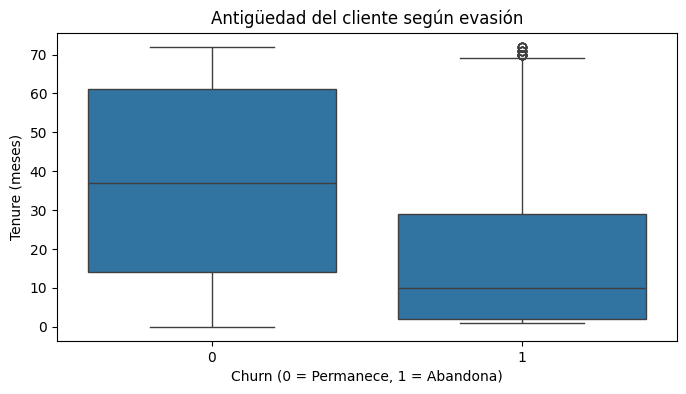

In [92]:
fig, ax = plt.subplots(figsize=(8,4))

sns.boxplot(
    data=df_normalizado,
    x='churn',
    y='tenure',
    ax=ax
)

ax.set(
    title='Antigüedad del cliente según evasión',
    xlabel='Churn (0 = Permanece, 1 = Abandona)',
    ylabel='Tenure (meses)'
)

plt.show()

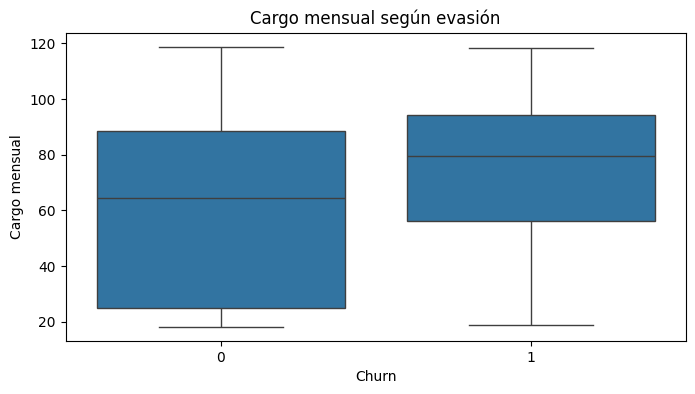

In [93]:
fig, ax = plt.subplots(figsize=(8,4))

sns.boxplot(
    data=df_normalizado,
    x='churn',
    y='charges_monthly',
    ax=ax
)

ax.set(
    title='Cargo mensual según evasión',
    xlabel='Churn',
    ylabel='Cargo mensual'
)

plt.show()

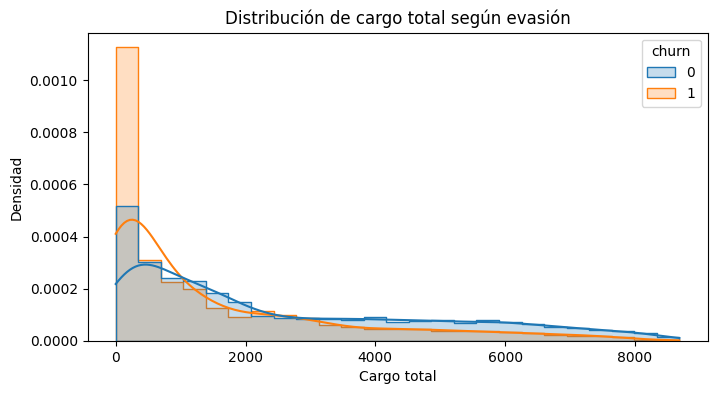

In [102]:
fig, ax = plt.subplots(figsize=(8,4))

sns.histplot(
    data=df_normalizado,
    x='charges_total',
    hue='churn',
    kde=True,
    element='step',
    stat='density',
    common_norm=False,
    ax=ax
)

ax.set(title='Distribución de cargo total según evasión', xlabel='Cargo total', ylabel='Densidad')

plt.show()

#📄Informe final

### Distribución general del churn

Se pudo observar que aproximadamente 1 de cada 4 clientes cancela el servicio, representando un 25.7% de toda la clientela.


### Evasión por variables categóricas

Se analizaron variables como:
* Tipo de contrato
* Género
* Servicio de internet
* Medios de pago

Hubieron distintos hallazgos clave, uno de los mas importante fue que los contratos mensuales (month-to-month) tienen una mayor tasa de evasión que los contratos de 1 o 2 años, lo que sugiere que los contratos de mayor duración favorecen la retención de clientes. Otro ejemplo es que hay una diferencia notable en el abandono del servicio por los clientes que pagan a través del cheque electrónico lo que podría sugerir la conveniencia de los medios de pago automáticos.


### Evasión por variables numéricas

Se compararon distribuciones de:
* Antigüedad (tenure)
* Cargo mensual
* Cargo total acumulado

Los principales insights encontrados son:
* Los clientes que abandonan son en su mayoria los que tienen poca antigüedad.
* Los cargos mensuales más altos se asocian con una mayor probabilidad de evasión.
* Los clientes que cancelan presentan menor cargo total acumulado que es coincidente con una menor permanencia.


### Conclusiones

La evasión se concentra en clientes que tienen contratos mensuales.
El abandono suele ocurrir en etapas tempranas.
La promoción de contratos de mayor duración podría favorecer la permanencia.
En ciertos segmentos se puede visibilizar una mayor sensibilidad a los precios, que podrían fomentar la evasión.
Lo ideal sería diseñar estrategias de retención tempranas ya que el mayor volumen de evasores se da en los primeros meses del contrato.

